<a href="https://colab.research.google.com/github/SalmaAnindhia/PemMes_25_Salma/blob/main/JS06/JS06_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np
import pandas as pd

In [18]:
train_dir = "images/training/"
test_dir = "images/test/"

In [21]:
def load_dataset(img_dir):
    p = Path(img_dir)
    dirs = p.glob('*')

    img_list = []

    for dir in dirs:
        label = str(dir).split('/')[-1]
        for file in dir.glob('*.jpg'):
            img = mpimg.imread(file)

            if not img is None:
                img_list.append((img, label))

    return img_list

In [22]:
train_img = load_dataset(train_dir)

In [23]:
train_img[0]

(array([[[24, 25, 17],
         [21, 22, 14],
         [20, 21, 13],
         ...,
         [12, 10,  0],
         [18, 16,  4],
         [22, 20,  8]],
 
        [[59, 60, 52],
         [52, 53, 45],
         [51, 52, 44],
         ...,
         [35, 33, 21],
         [36, 34, 22],
         [37, 35, 23]],
 
        [[59, 60, 52],
         [51, 52, 44],
         [48, 49, 41],
         ...,
         [35, 33, 21],
         [33, 31, 19],
         [32, 30, 18]],
 
        ...,
 
        [[64, 70, 58],
         [64, 70, 58],
         [65, 71, 59],
         ...,
         [42, 57, 50],
         [42, 59, 51],
         [43, 60, 52]],
 
        [[75, 81, 69],
         [74, 80, 68],
         [72, 78, 66],
         ...,
         [36, 51, 44],
         [39, 54, 47],
         [40, 57, 49]],
 
        [[77, 83, 73],
         [76, 82, 72],
         [75, 81, 71],
         ...,
         [29, 42, 33],
         [33, 46, 37],
         [35, 51, 41]]], dtype=uint8),
 'night')

In [16]:
!unzip -q images.zip

In [24]:
pick_random = np.random.randint(0, len(train_img))

print(f'Image {pick_random}')
print(train_img[pick_random][0].shape)

Image 162
(471, 640, 3)


In [25]:
def random_img_viz(img_list):
    rand_num = np.random.randint(0, len(img_list))

    img = img_list[rand_num][0]
    label = img_list[rand_num][1]
    label_str = 'day' if label == 1 else 'night'

    plt.imshow(img)
    print(f'Shape\t: {img.shape}')
    print(f'Label\t: {label}')

Shape	: (700, 1280, 3)
Label	: night


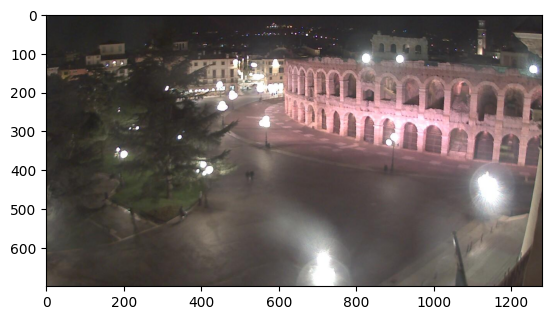

In [26]:
random_img_viz(train_img)

In [27]:
def standarized_input(image):
    std_img = cv2.resize(image, (1100,600))

    return std_img

In [28]:
def label_encoder(label):
    num_val = 0

    if(label == 'day'):
        num_val = 1

    return num_val

In [29]:
def preprocess(img_list):
    std_img_list = []

    for item in img_list:
        image = item[0]
        label = item[1]

        std_img = standarized_input(image)

        img_label = label_encoder(label)

        std_img_list.append((std_img, img_label))

    return std_img_list

In [30]:
train_std_img_list = preprocess(train_img)

In [31]:
pick_random = np.random.randint(0, len(train_std_img_list))

print(f'Image {pick_random}')
print(train_std_img_list[pick_random][0].shape)

Image 48
(600, 1100, 3)


Shape	: (600, 1100, 3)
Label	: 0


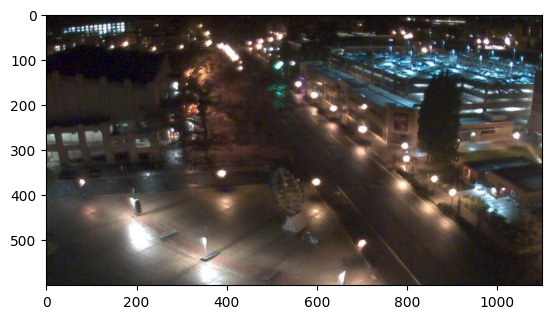

In [33]:
random_img_viz(train_std_img_list)

In [34]:
def avg_brightness(image):
    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    sum_brightness = np.sum(img_hsv[:,:,2]) # take the 3rb value which is the V channel
    area = image.shape[0] * image.shape[1]
    avg = sum_brightness / area

    return avg


Image 56
Avg Brighness: 24.5015


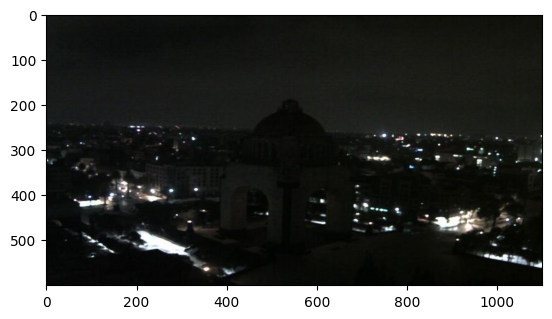

In [35]:
rand_img = np.random.randint(0, len(train_std_img_list))

feature_img = train_std_img_list[rand_img][0]

avg_img = avg_brightness(feature_img)

print(f'Image {rand_img}')
print(f'Avg Brighness: {avg_img:.4f}')
plt.imshow(feature_img)

In [36]:
def predict_label(img, threshold):
    avg = avg_brightness(img)
    pred = 0

    if avg > threshold:
        pred = 1

    return pred

Image 27
Actual label: 0
Predicted label: 0


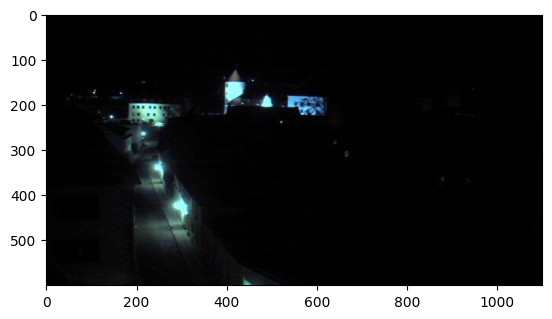

In [37]:
rand_img = np.random.randint(0, len(train_std_img_list))

pred = predict_label(train_std_img_list[rand_img][0], threshold=120)

print(f'Image {rand_img}')
print(f'Actual label: {train_std_img_list[rand_img][1]}')
print(f'Predicted label: {pred}')
plt.imshow(train_std_img_list[rand_img][0])

In [38]:
def evaluate(img_list, threshold):
    miss_labels = []

    for file in img_list:
        img = file[0]
        label = file[1]

        pred_label = predict_label(img, threshold)

        if pred_label != label:
            miss_labels.append((img, pred_label, label))

    total_img = len(img_list)
    corr_pred = total_img - len(miss_labels)
    accuracy = corr_pred / total_img

    print(f'Accuracy: {accuracy:.4f}')

In [39]:
evaluate(train_std_img_list, threshold=120)

Accuracy: 0.8417


In [40]:
test_img = load_dataset(test_dir)

test_std_img_list = preprocess(test_img)

evaluate(test_std_img_list, threshold=120)

Accuracy: 0.8688


In [41]:
def extract_avg_bright_feature(img_list):
    avg_list = []
    labels = []

    for img in img_list:
        img_avg = avg_brightness(img[0])
        img_label = img[1]

        avg_list.append(img_avg)
        labels.append(img_label)

    data = np.column_stack((avg_list, labels))
    df = pd.DataFrame(data, columns=['AVG_BRIGHT', 'LABELS'])

    return df

In [42]:
train_avg_img = extract_avg_bright_feature(train_std_img_list)
print(f'Shape: {train_avg_img.shape}')
train_avg_img.head()

Shape: (240, 2)


,AVG_BRIGHT,LABELS
0,85.889741,0.0
1,98.982730,0.0
2,98.714723,0.0
3,99.819608,0.0
4,92.618733,0.0


In [43]:
test_avg_img = extract_avg_bright_feature(test_std_img_list)
print(f'Shape: {test_avg_img.shape}')
test_avg_img.head()

Shape: (160, 2)


,AVG_BRIGHT,LABELS
0,93.822077,0.0
1,38.777894,0.0
2,41.211485,0.0
3,46.693686,0.0
4,13.228938,0.0


In [44]:
from sklearn.svm import SVC

X_train = train_avg_img.iloc[:,0].values.reshape(-1,1)
y_train = train_avg_img.iloc[:,1]
X_test = test_avg_img.iloc[:,0].values.reshape(-1,1)
y_test = test_avg_img.iloc[:,1]

model = SVC()
model.fit(X_train, y_train)

SVC()

In [45]:
from sklearn.metrics import accuracy_score

y_train_pred = model.predict(X_train)

acc_train = accuracy_score(y_train, y_train_pred)

y_test_pred = model.predict(X_test)

acc_test = accuracy_score(y_test, y_test_pred)

print(f'Accuracy on train: {acc_train}')
print(f'Accuracy on test: {acc_test}')

Accuracy on train: 0.8583333333333333
Accuracy on test: 0.9
